# <h1 style="color: yellow;">Causal inference - Hours studied and tutoring sessions</h1>

## Models defnitions and DAG

In [ ]:
#What is the causal effect of participating in more tutoring sessions (Tutoring_Sessions) and more Hours_studied on Exam_Score, 
#considering Parental_Involvement as a control variable?

In [ ]:
#DAG:

#Outcome: Exam_Score
#Treatment 1: Hours_Studied
#Treatment 2: Tutoring_Sessions
#Confounder/control: Parental_Involvement

#ExamScore= β0 ​+ β1​HoursStudied + β2​TutoringSessions + β3​ParentalInvolvement

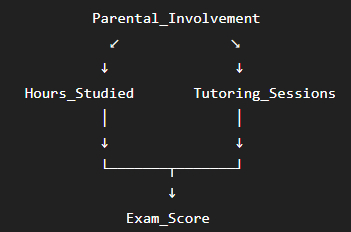

In [ ]:
#Model 1 — Effect of study hours
#Model 2 — Effect of tutoring Sessions
#Model 3 — Both effects

## Libraries

In [2]:
import pandas as pd
import statsmodels.formula.api as smf

## Transformed dataset (from EDA)

In [4]:
#Students performance factors for model dataset
student_performance_factors_for_model = pd.read_csv('../Dataset/student_performance_factors_for_model.csv')
display(student_performance_factors_for_model.head(5))
print(student_performance_factors_for_model.info())

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,low,high,no,7,73,low,yes,0,low,medium,public,positive,3,no,high school,near,male,67
1,19,64,low,medium,no,8,59,low,yes,2,medium,medium,public,negative,4,no,college,moderate,female,61
2,24,98,medium,medium,yes,7,91,medium,yes,2,medium,medium,public,neutral,4,no,postgraduate,near,male,74
3,29,89,low,medium,yes,8,98,medium,yes,1,medium,medium,public,negative,4,no,high school,moderate,male,71
4,19,92,medium,medium,yes,6,65,medium,yes,3,medium,high,public,neutral,4,no,college,near,female,70


<class 'pandas.DataFrame'>
RangeIndex: 6377 entries, 0 to 6376
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6377 non-null   int64
 1   Attendance                  6377 non-null   int64
 2   Parental_Involvement        6377 non-null   str  
 3   Access_to_Resources         6377 non-null   str  
 4   Extracurricular_Activities  6377 non-null   str  
 5   Sleep_Hours                 6377 non-null   int64
 6   Previous_Scores             6377 non-null   int64
 7   Motivation_Level            6377 non-null   str  
 8   Internet_Access             6377 non-null   str  
 9   Tutoring_Sessions           6377 non-null   int64
 10  Family_Income               6377 non-null   str  
 11  Teacher_Quality             6377 non-null   str  
 12  School_Type                 6377 non-null   str  
 13  Peer_Influence              6377 non-null   str  
 14  Physical_Activity  

In [9]:
student_performance_factors_for_model["Parental_Involvement"].unique()

<StringArray>
['low', 'medium', 'high']
Length: 3, dtype: str

## Parental involvement variable treatment (dummy)

In [10]:
#Dataframe defnition
causal_df = student_performance_factors_for_model[
    [
        "Exam_Score",
        "Hours_Studied",
        "Tutoring_Sessions",
        "Parental_Involvement"
    ]
].copy()

#Low and Medium will be the categorical columns and High will be the reference column
causal_df = pd.get_dummies(
    causal_df,
    columns=["Parental_Involvement"],
    drop_first=True,
    dtype=int
)
display(causal_df)

,Exam_Score,Hours_Studied,Tutoring_Sessions,Parental_Involvement_low,Parental_Involvement_medium
0,67,23,0,1,0
1,61,19,2,1,0
2,74,24,2,0,1
3,71,29,1,1,0
4,70,19,3,0,1
...,...,...,...,...,...
6372,68,25,1,0,0
6373,69,23,3,0,0
6374,68,20,3,0,1
6375,68,10,2,0,0


## Model 1 - Hours_Studied (OLS regression analysis)

In [14]:
#What is the relationship between an additional hour of study and Exam_Score, controlling for Parental_Involvement?
model_1 = smf.ols(
    """
    Exam_Score ~ Hours_Studied
    + Parental_Involvement_low
    + Parental_Involvement_medium
    """,
    data=causal_df
).fit()

print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.227
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     622.9
Date:                Mon, 24 Aug 2026   Prob (F-statistic):               0.00
Time:                        19:12:09   Log-Likelihood:                -16893.
No. Observations:                6377   AIC:                         3.379e+04
Df Residuals:                    6373   BIC:                         3.382e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

## Model 2 - Tutoring_Sessions (OLS regression analysis)

In [20]:
#What is the relationship between an additional tutoring session and Exam_Score, controlling for Parental_Involvement?
model_2 = smf.ols(
    """
    Exam_Score ~ Tutoring_Sessions
    + Parental_Involvement_low
    + Parental_Involvement_medium
    """,
    data=causal_df
).fit()

print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     110.2
Date:                Mon, 24 Aug 2026   Prob (F-statistic):           1.43e-69
Time:                        19:23:03   Log-Likelihood:                -17552.
No. Observations:                6377   AIC:                         3.511e+04
Df Residuals:                    6373   BIC:                         3.514e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

## Model 3 - Both (OLS regression analysis)

In [21]:
#What is the relationship between an additional tutoring session/hours studied and Exam_Score, controlling for Parental_Involvement?
model_3 = smf.ols(
    """
    Exam_Score ~ Hours_Studied
    + Tutoring_Sessions
    + Parental_Involvement_low
    + Parental_Involvement_medium
    """,
    data=causal_df
).fit()

print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.252
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     536.6
Date:                Mon, 24 Aug 2026   Prob (F-statistic):               0.00
Time:                        19:23:05   Log-Likelihood:                -16788.
No. Observations:                6377   AIC:                         3.359e+04
Df Residuals:                    6372   BIC:                         3.362e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

## Model comparison

In [22]:
#3 models coeficient comparasion
results = pd.DataFrame({
    "Model": [
        "Hours Studied",
        "Tutoring Sessions",
        "Both"
    ],
    "Hours_Studied": [
        model_1.params.get("Hours_Studied", None),
        None,
        model_3.params.get("Hours_Studied", None)
    ],
    "Tutoring_Sessions": [
        None,
        model_2.params.get("Tutoring_Sessions", None),
        model_3.params.get("Tutoring_Sessions", None)
    ],
    "R_squared": [
        model_1.rsquared,
        model_2.rsquared,
        model_3.rsquared
    ]
})

print(results)

               Model  Hours_Studied  Tutoring_Sessions  R_squared
0      Hours Studied       0.291681                NaN   0.226738
1  Tutoring Sessions            NaN           0.486671   0.049323
2               Both       0.292736           0.501187   0.251960


## Causal inference result

In [ ]:
#Controlling for parental involvement, the analysis suggests that both tutoring sessions and study hours have a positive effect on exam scores. 
#Each additional tutoring session is associated with an estimated increase of 0.501 points in the Exam Score, while each additional hour studied is associated with an increase of approximately 0.293 points. 
#The combined model achieved an R² of 0.252, indicating that these variables explain approximately 25.2% of the variation in exam scores. 
#Under the causal assumptions of the model, the results suggest that increasing tutoring participation has a stronger marginal effect on exam performance than increasing study hours.

In [ ]:
#These results already allow us to draw some interesting lessons—but not yet call the coefficients causal effects.
#In this models analysis, simultaneously controlling for Hours_Studied and Tutoring_Sessions does not significantly alter the estimated association of each.

In [ ]:
#Students who are struggling may receive more sessions precisely because they are having difficulty.
#In other words, more tutoring sessions do not mean the students will achieve an excellent grade, because they may have difficulty to study